 <center> <h1> <b> Pattern Recognition and Machine Learning (EE2802 - EE5610) </b> </h1> </center>

<b> Programming Assignment - 04 : Q-Learning</b>


In this assignment, you will implement a Q-learning algorithm to learn the optimal policy for a Markov Decision Process (MDP) .

<b> Instructions </b>
1. Plagiarism is strictly prohibited.
2. Delayed submissions are not accepted
3. For each question, report your understanding and the corresponding outcomes. Answers without proper observations will not be awarded marks.
4. Writing the code alone, without executing it, will result in zero marks.









**(Computer Assignment: Q-Learning for Phone Battery Management)** Notice
that the Markov chain is parameterized by α, β, δ, ε,φ, κ, η that are **unknown** in practice.
Here we explore a simple **reinforcement learning algorithm** called **Q-learning** that
iteratively estimates the optimal action value function (and hence the optimal policy
$π^∗$). Intuitively, this is done by replacing the expectation in the Bellman optimality
equation for the action value function with observed samples, and repeatedly refining
estimates based on observed data. Notably, it achieves this **without** the knowledge of
the Markov chain parameters.

In many cases (especially in Markov chains arising in communications and signal
processing applications), this algorithm can run on a single sample path. In others, over multiple sample paths called episodes. Moreover, the learning rate α parameter below typically needs to vary with iteration to guarantee convergence (see, e.g., Sayed, Chap. 45).

In this problem, we use a simplified Q-learning algorithm that uses a single (long) sample path and a constant (small) learning rate. Implement the pseudocode below:





**Note: This assignment references HW 6**


---

##  Problem Setup

- **States:** S = \{1, 2, 3\} ,  **Actions:** A = \{1, 2\}


**Parameters:**

- Step size $\alpha$  
- Discount factor $\gamma$  
- Exploration rate $\epsilon$

($\alpha$ and $\epsilon$ in this algorithm are unrelated to the Markov chain parameters above.)

**Typical values:**

- $\alpha$ = 0.1
- $\gamma$ = 0.9  
-  $\epsilon$ = 0.1   
Feel free to experiment with different values
---

##  Q-Learning Algorithm

Initialize:
-  Q(s,a) $\leftarrow$ 0  for all  s $\in$ S, a $\in $A
- state  s $\in$ S

**for**  t = 1 to T  (typical T $\approx$ 10^4 \):

> **ε-greedy Action Selection** With probability $\epsilon$, choose a $\in$ A uniformly at random. Otherwise, choose: $a = \arg\max_{a'} Q(s,a')$

> **Observe reward**: $r = R(S_t, A_t, S_{t+1})$ (see above) and the next state $s' = S_{t+1}$

> **Q-learinin Update :**
$Q(s,a) \leftarrow Q(s,a) + \alpha \left[ r + \gamma \max_{a'} Q(s',a') - Q(s,a) \right]$


> **State Update :** $s \leftarrow s'$

**end for**

**Output :**  greedy policy : $\pi(s) = \arg\max_a Q(s,a)$


Simulate transitions using the given transition probability matrices (HW6), but the algorithm cannot use this knowledge. Your code should:

## Tasks

---

### (a) [30 Marks]

- Plot the evolution of $\max_a Q(s,a)$ for each state s vs iterations. Compare the **final greedy policy** with the policies obtained in Problem (3) in HW6.

- Verify that the learned policy **stabilizes over time**.

---

### (b) [15 Marks]

Repeat part (a) using different values of Exploration rate $\epsilon$ and Step size $\alpha$ on the evolution

---

### (c) [25 Marks]
Plot the extracted **greedy action** (final step in the algorithm) for each state as a function of $\rho$, and compare it with the analytical value functions obtained in **Q3** using the **Poisson equation**.

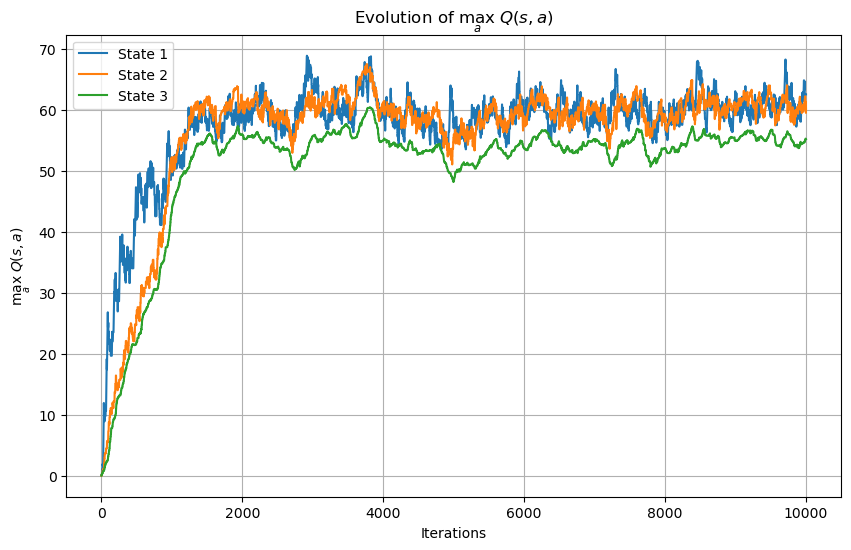

Learned Policy Matrix:
[[0 1]
 [0 1]
 [1 0]]


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Model functions
def next_state(P, state, action):
    state_space = np.arange(0, P.shape[1], step=1)
    return np.random.choice(state_space, p=P[action][state].flatten())

def reward(state, action, next_state, rho):
    next_state += 1
    action += 1

    if action == 2 and next_state == 3:
        return 0
    elif action == 1:
        return 1
    else:
        return rho

# Learning functions
def next_action(Q, state, epsilon):
    if np.random.binomial(n=1, p=epsilon, size=1):
        action_space = np.arange(0, Q.shape[1], step=1)
        return np.random.choice(action_space)
    else:
        return np.argmax(Q[state].flatten())

def update_Q(Q, state, action, next_state, reward, discount, lr):
    optimal_Q = np.max(Q[next_state].flatten())
    Q[state, action]= Q[state, action] + lr * (reward + discount * (optimal_Q) - Q[state, action])
    return Q

# Hyperparameters
rho = 10 
gamma = 0.9 
lr = 0.1
epsilon = 0.1
iterations = 10000

alpha = 1/2
beta = 1/4
delta = 1/4
e = 15/16
phi = 1/4
kappa = 1/2
eta = 1/4

P = np.array([
    [
        [1 - alpha, 0, alpha],
        [beta, 1 - beta - delta, delta],
        [0, e, 1 - e]
    ],
    [
        [1 - phi, 0, phi],
        [kappa, 1 - kappa - eta, eta],
        [0, 0, 1]
    ]
])

Q = np.zeros((3, 2))
max_Q_history = {0: [], 1: [], 2: []}

current_state = 0
for _ in range(iterations):
    action = next_action(Q, current_state, epsilon)
    s_next = next_state(P, current_state, action)
    r = reward(current_state, action, s_next, rho)
    
    Q = update_Q(Q, current_state, action, s_next, r, gamma, lr)
    current_state = s_next
    
    for s in range(3):
        max_Q_history[s].append(np.max(Q[s]))

plt.figure(figsize=(10, 6))
for s in range(3):
    plt.plot(max_Q_history[s], label=f'State {s+1}')

plt.title('Evolution of $\\max_a\\;Q(s,a)$')
plt.xlabel('Iterations')
plt.ylabel('$\\max_a\\;Q(s,a)$')
plt.legend()
plt.grid(True)
plt.show()

learned_policy = np.argmax(Q, axis=1)
learned_policy_matrix = np.zeros((3, 2), dtype=int)
for s in range(3):
    learned_policy_matrix[s, learned_policy[s]] = 1

print("Learned Policy Matrix:")
print(learned_policy_matrix)

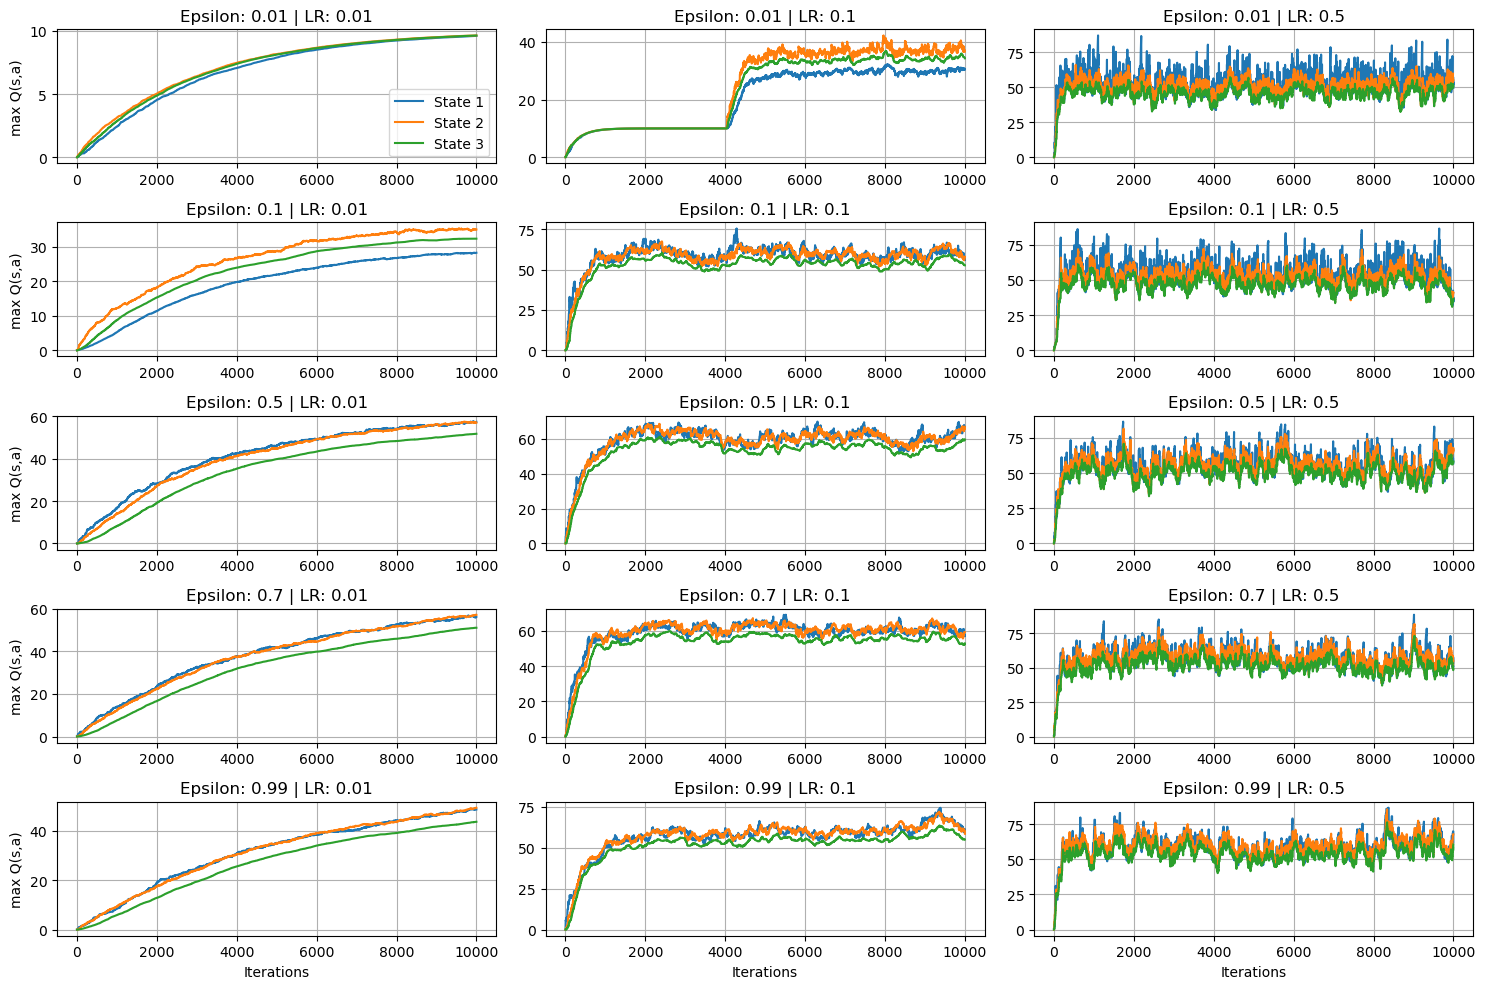

In [2]:
epsilons = [0.01, 0.1, 0.5, 0.7, 0.99]
learning_rates = [0.01, 0.1, 0.5]

fig, axes = plt.subplots(len(epsilons), len(learning_rates), figsize=(15, 10))

for i, epsilon_val in enumerate(epsilons):
    for j, lr_val in enumerate(learning_rates):
        Q = np.zeros((3, 2))
        max_Q_hist = {0: [], 1: [], 2: []}
        curr_s = 0
        
        for _ in range(iterations):
            act = next_action(Q, curr_s, epsilon_val)
            s_next = next_state(P, curr_s, act)
            r = reward(curr_s, act, s_next, rho)
            
            Q = update_Q(Q, curr_s, act, s_next, r, gamma, lr_val)
            curr_s = s_next
            
            for s in range(3):
                max_Q_hist[s].append(np.max(Q[s]))
                
        ax = axes[i, j]
        for s in range(3):
            ax.plot(max_Q_hist[s], label=f'State {s+1}')
        
        ax.set_title(f'Epsilon: {epsilon_val} | LR: {lr_val}')
        ax.grid(True)
        if i == len(epsilons) - 1:
            ax.set_xlabel('Iterations')
        if j == 0:
            ax.set_ylabel('max Q(s,a)')

        if(i == 0 and j == 0):
            ax.legend()

plt.tight_layout()
plt.show()

Value Function $v^{\pi}$(s) at rho = 10.0:
  State 1: 60.0832
  State 2: 61.7239
  State 3: 55.8532


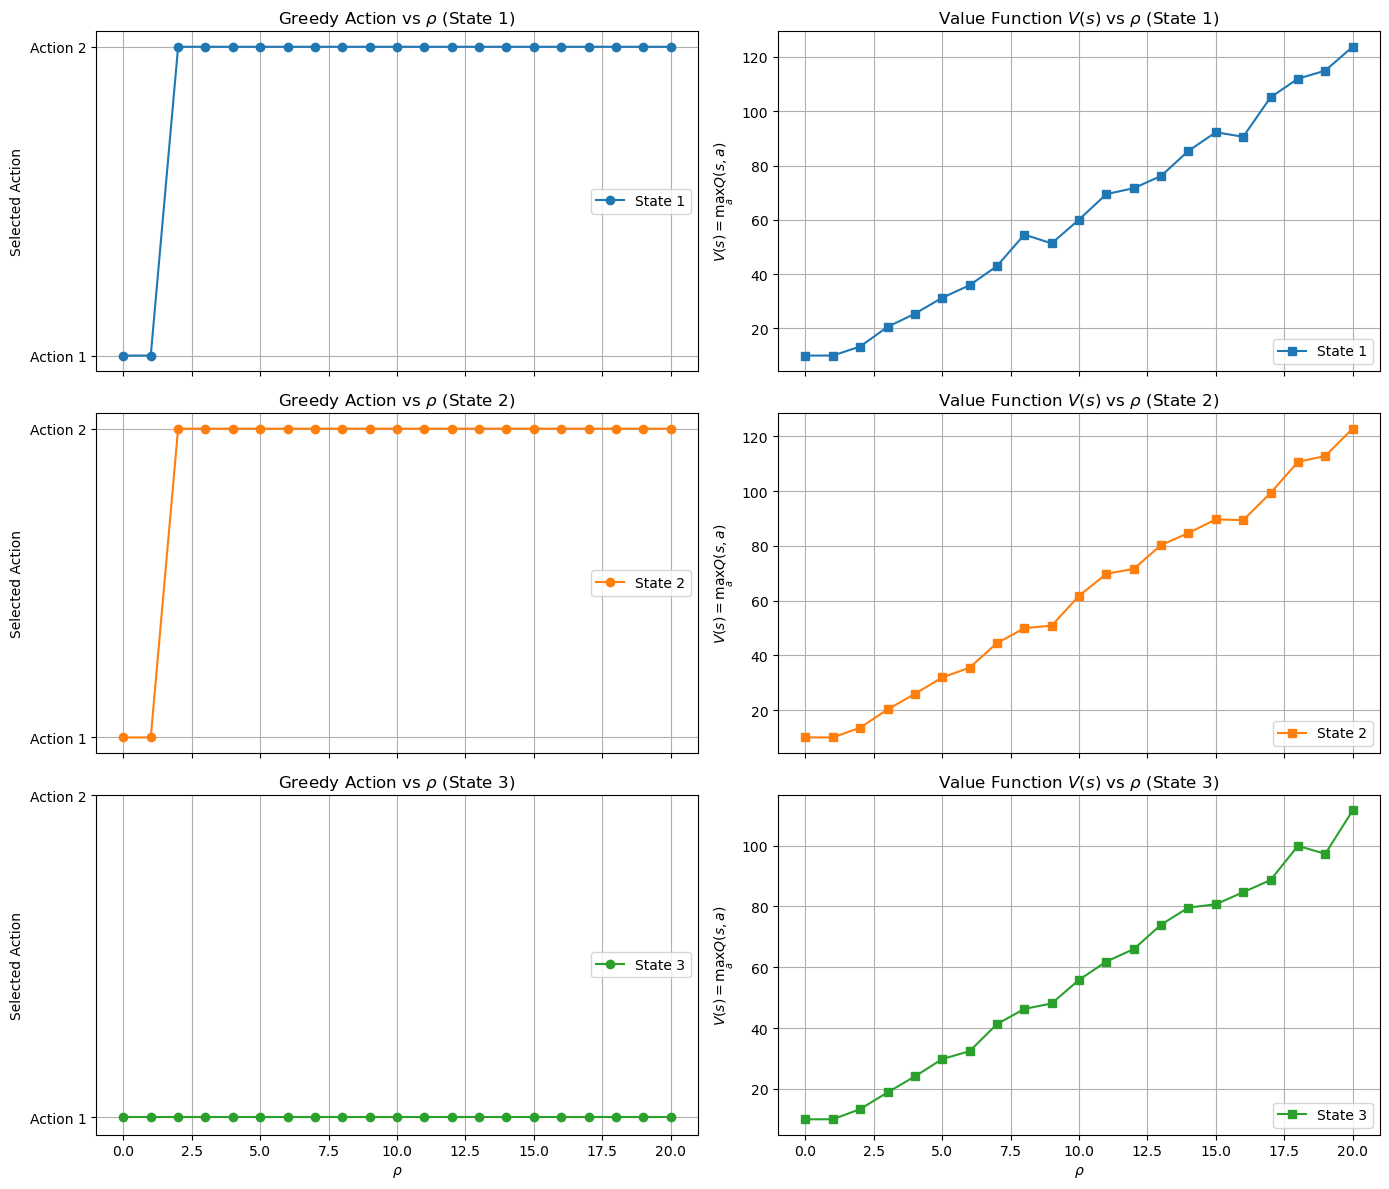

In [5]:
rho_values = np.linspace(0, 20, 21)
epsilon = 0.1
lr = 0.1

policy_history = {0: [], 1: [], 2: []}
value_history = {0: [], 1: [], 2: []}

for current_rho in rho_values:
    Q = np.zeros((3, 2))
    curr_s = 0
    
    for _ in range(10*iterations):
        act = next_action(Q, curr_s, epsilon)
        s_next = next_state(P, curr_s, act)
        r = reward(curr_s, act, s_next, current_rho)
        
        Q = update_Q(Q, curr_s, act, s_next, r, gamma, lr)
        curr_s = s_next
        
    final_policy = np.argmax(Q, axis=1)
    final_value = np.max(Q, axis=1)
    
    # Print the value function specifically for rho = 10
    if current_rho == 10.0:
        print("Value Function $v^{\\pi}$(s) at rho = 10.0:")
        for s in range(3):
            print(f"  State {s+1}: {final_value[s]:.4f}")
    
    for s in range(3):
        policy_history[s].append(final_policy[s])
        value_history[s].append(final_value[s])

fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True)

for s in range(3):
    # Left Column: Policy
    axes[s, 0].plot(rho_values, policy_history[s], marker='o', color=f'C{s}', label=f'State {s+1}')
    axes[s, 0].set_title(f'Greedy Action vs $\\rho$ (State {s+1})')
    axes[s, 0].set_ylabel('Selected Action')
    axes[s, 0].set_yticks([0, 1])
    axes[s, 0].set_yticklabels(['Action 1', 'Action 2'])
    axes[s, 0].grid(True)
    axes[s, 0].legend(loc="right")
    
    # Right Column: Value Function (Total Expected Reward)
    axes[s, 1].plot(rho_values, value_history[s], marker='s', color=f'C{s}', label=f'State {s+1}')
    axes[s, 1].set_title(f'Value Function $V(s)$ vs $\\rho$ (State {s+1})')
    axes[s, 1].set_ylabel('$V(s) = \\max_a Q(s,a)$')
    axes[s, 1].grid(True)
    axes[s, 1].legend(loc="lower right")

axes[-1, 0].set_xlabel('$\\rho$')
axes[-1, 1].set_xlabel('$\\rho$')

plt.tight_layout()
plt.show()

<b> Report your observations for each part </b>

1. The Q-learning algorithm successfuly learns the policy $\underline{\Pi_3}$ which is also derived in the HW6 as turning out to be the best with each state in $v^{\pi_3}$ having greater value than policies $\underline{\pi_1}$ and $\underline{\Pi_2}$. The evolution of $\max_a Q(s,a)$ clearly shows the values gradually increasing then settling down after a point (although very noisily) having values around 60 after about 4000 iterations.

2. There is an immediate jump at around the 1500 iteration mark which can be accounted to the concept of $\textbf{Exploitation vs Exploration}$ in which the $\epsilon$ probability in which we choose a random $a \in A$ (also coined exploration) and otherwise we choose the optimal value $a = \arg\max_{a'} Q(s,a')$ (coined exploitation). This allows the algorithm to get out of local minimas and traps that would converge to some low value if not for this exploration. Because of this, there is a straight jump at the 1500 iteration mark in which the agent finds a better minima to travel to after exploring.

3. In this particular policy, the values for $\max_{a} Q(s,a)$ for state 3 are eventually lesser than that of state 1 and 2 because of the inherent lesser reward given to state 3 after taking action 2 (0 reward) which promotes the agent to "stay out" of state 3.

4. As we change $\epsilon$ around (keeping the learning rate constant), the agent "learns" faster and the evolution graph shows steeper ascents, but only uptil a point. At lower $\epsilon$ ($\sim 0.001$) there is that jump mentioned in point $3$ with more prominent jumps with lower $\epsilon$ which can be accounted to less exploration by the agent and randomly stumbling upon a better minima after a point with lesser probability. At higher $\epsilon$ ($\sim 0.7$ or $\sim 0.9$), the agent explores too much and only gradually reaches the "steady state" in the evolution graph. At medium $\epsilon$ ($\sim 0.1$), the agent explores decently and convergence is "fast enough".

5. As we change learning rate $\alpha$ (keeping $\epsilon$ constant), the speed of convergence changes. At lower $\alpha$ ($\sim 0.01$), the speed is very slow and it does not even converge properly (till 10,000 iterations). At higher $\alpha$ ($\sim 0.5$), the evolution graph has too many oscillations and is very very noisy. At medium $\alpha$ ($\sim 0.1$) it converges properly and oscillations are bearable.

6. After $\rho = 2$ the optimal policy turns out to be action 2 for state 1 and 2 and action 1 for state 3 (calculated in HW6 with $\rho = 10$). But for $\rho = 1$ and $0$, the policy is to take action 1 always as it intuitevely provides a reward of 1 everytime which is anyways better.

7. For $\rho = 10$ (as stated in HW6) the observed values of value function from q-learning are: $v^{\pi} = [60.0832, 61.7239, 55.8532]$ and calculated values from Poisson's equation in HW6 are $v^{\pi} = [62.486, 62.486, 56.925]$
